# 09 — DenseNet-121 transfer learning · Deliverable 2

Retrains the final model into **your own** Drive, under `plant_recognition/deliverable2/`.

**Recipe (unchanged):** ImageNet DenseNet-121, 128 px, batch 32 ·
**phase 1** head only, backbone frozen, LR 1e-3, 5 epochs ·
**phase 2** backbone unfrozen with BatchNorm kept frozen, LR 1e-5, early stopping.
`class_weight` is passed to **both** `fit` calls, and the cell asserts that the trainable-parameter
count actually rises in phase 2 — a silent no-op fine-tune is what cost the ResNet50 run.

**Guard rails in this notebook**

1. The split is **loaded** from `00_split/`, never rebuilt. The notebook prints `SPLIT_ID` and
   **stops** unless it equals `9e33ec57c1ec`.
2. The model is written to `02_models/densenet121.keras` the moment training ends — **before**
   any evaluation, so a runtime wipe during eval does not cost the hour.
3. The test split is never turned into a dataset. It is read only as bytes, for the fingerprint.

> **Before you run:** Runtime ▸ Change runtime type ▸ **T4 GPU**, then Runtime ▸ Run all.
> ~45–60 min. Set `SMOKE_TEST = True` in the config block first for a ~3-minute dry run of the
> whole path (it writes to a separate `_smoke` filename and touches nothing real).

Expected: **val macro-F1 ≈ 0.993**, min per-class recall ≈ 0.946. More than ~0.01 off means
something changed — check the `SPLIT_ID` first.

## 1. Colab setup

Kaggle credentials from Secrets (with the retry — the Secrets API times out intermittently),
Drive mounted, GPU confirmed.

In [ ]:
# Kaggle credentials from Colab Secrets (with retry) + mount Drive. Harmless when run locally.
import os, time

ON_COLAB = False
try:
    from google.colab import userdata, drive
    ON_COLAB = True
except ModuleNotFoundError:
    print("Not on Colab - using local ~/.kaggle/kaggle.json and a local folder in place of Drive.")

if ON_COLAB:
    ok = False
    for attempt in range(1, 4):
        try:
            os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
            os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")
            print(f"Kaggle credentials loaded from Colab Secrets (attempt {attempt}).")
            ok = True
            break
        except Exception as e:
            print(f"  attempt {attempt}: Secrets not ready ({type(e).__name__}); retrying in 3s...")
            time.sleep(3)
    if not ok:
        print("")
        print("Colab Secrets did not respond. Fixes, in order:")
        print("  1) RE-RUN this cell - the timeout is almost always transient.")
        print("  2) Left sidebar -> key icon -> confirm KAGGLE_USERNAME and KAGGLE_KEY exist,")
        print("     each with 'Notebook access' toggled ON, then re-run.")
        print("  3) Still failing? Set os.environ['KAGGLE_USERNAME'/'KAGGLE_KEY'] manually here.")
    drive.mount("/content/drive")

import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
print("\nTensorFlow", tf.__version__, "| GPU:", gpus if gpus else "NONE - switch the runtime to T4 before training")

Kaggle credentials loaded from Colab Secrets (attempt 1).
Mounted at /content/drive

TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

The only config block in the notebook. Everything below reads from here.

In [ ]:
# ---- the one config block ----
from pathlib import Path
from collections import deque
import json, time, random, shutil, hashlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications import densenet
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, accuracy_score, recall_score, precision_score,
                             confusion_matrix, classification_report)

sns.set_theme()
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

# ---- the split this notebook is allowed to run on ----
SPLIT_ID_EXPECTED = "9e33ec57c1ec"

# ---- Drive layout ----
_drive     = Path("/content/drive/MyDrive")
DRIVE_ROOT = _drive if _drive.exists() else Path.home()          # local fallback off Colab
D2         = DRIVE_ROOT / "plant_recognition" / "deliverable2"
SPLIT_DIR  = D2 / "00_split"
MODELS_DIR = D2 / "02_models"
RESULTS    = D2 / "03_results"
FIGURES    = D2 / "04_figures"
for d in (MODELS_DIR, RESULTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)
SPLIT_CSV = {s: SPLIT_DIR / f"split_{s}.csv" for s in ("train", "val", "test")}

# ---- raw images (local runtime disk - fast; Drive is for artifacts only) ----
PV_DIR   = Path.home() / "plant_recognition" / "plantvillage"
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

# ---- recipe (do not change - these are the numbers the report quotes) ----
IMG_SIZE     = 128
BATCH_SIZE   = 32
DROPOUT      = 0.3
LR_HEAD      = 1e-3          # phase 1: new head, backbone frozen
HEAD_EPOCHS  = 5             # phase 1: fixed, no early stopping
LR_FINETUNE  = 1e-5          # phase 2: backbone unfrozen, BatchNorm frozen
FT_EPOCHS    = 20            # phase 2: upper bound; early stopping normally ends it sooner
FT_PATIENCE  = 4

# ---- run switches ----
SMOKE_TEST      = False      # True -> ~200 train images/class, 1 epoch per phase, separate filename
SMOKE_PER_CLASS = 60
FORCE_RETRAIN   = False      # True -> retrain even if the checkpoint already exists on Drive

TAG          = "densenet121" + ("_smoke" if SMOKE_TEST else "")
MODEL_PATH   = MODELS_DIR / f"{TAG}.keras"
LOCAL_MODEL  = Path("/content") / f"{TAG}.keras" if ON_COLAB else Path.home() / f"{TAG}.keras"
HISTORY_JSON = RESULTS / f"{TAG}_history.json"

print("deliverable2 :", D2)
print("model out    :", MODEL_PATH)
print("images       :", PV_DIR)
print(f"recipe       : {IMG_SIZE}px, batch {BATCH_SIZE}, phase1 LR {LR_HEAD} x{HEAD_EPOCHS}, "
      f"phase2 LR {LR_FINETUNE} (early stop, patience {FT_PATIENCE})")
print(f"switches     : SMOKE_TEST={SMOKE_TEST}, FORCE_RETRAIN={FORCE_RETRAIN}")

deliverable2 : /content/drive/MyDrive/plant_recognition/deliverable2
model out    : /content/drive/MyDrive/plant_recognition/deliverable2/02_models/densenet121.keras
images       : /root/plant_recognition/plantvillage
recipe       : 128px, batch 32, phase1 LR 0.001 x5, phase2 LR 1e-05 (early stop, patience 4)
switches     : SMOKE_TEST=False, FORCE_RETRAIN=False


## 3. The split gate

The CSVs are **loaded** from Drive and the fingerprint is re-derived from their raw bytes. If the
`SPLIT_ID` is anything other than the frozen one, this cell raises and nothing downstream runs —
an incomparable number is worse than no number.

The test CSV is read here for its bytes only. It is never turned into a dataset in this notebook.

In [ ]:
# Load the canonical split and re-derive the fingerprint from the CSV bytes
missing = [str(p) for p in SPLIT_CSV.values() if not p.exists()]
assert not missing, f"split CSVs not found on Drive: {missing}\nRun 00_setup_and_split.ipynb first."

dfs = {s: pd.read_csv(SPLIT_CSV[s]) for s in SPLIT_CSV}

md5      = lambda p: hashlib.md5(Path(p).read_bytes()).hexdigest()
SPLIT_ID = hashlib.md5("".join(md5(SPLIT_CSV[s]) for s in ("train", "val", "test"))
                       .encode()).hexdigest()[:12]

print("SPLIT_ID          =", SPLIT_ID)
print("SPLIT_ID_EXPECTED =", SPLIT_ID_EXPECTED)
assert SPLIT_ID == SPLIT_ID_EXPECTED, (
    f"\n\nSTOP. Split fingerprint mismatch: got {SPLIT_ID}, expected {SPLIT_ID_EXPECTED}.\n"
    "This is NOT the frozen split, so any number produced here is not comparable with the\n"
    "rest of the report. Do not train. Check 00_split/fingerprint.txt and re-sync the CSVs.")

class_names = sorted(dfs["train"]["label"].unique())
name2idx    = {n: i for i, n in enumerate(class_names)}
n_classes   = len(class_names)
n_tot       = sum(len(d) for d in dfs.values())
assert n_classes == 38, f"expected 38 classes, found {n_classes}"
assert n_tot == 54_305, f"expected 54,305 rows, found {n_tot:,}"

print(f"\nOK  fingerprint matches  |  {n_tot:,} rows  |  {n_classes} classes")
print(f"train / val / test : {len(dfs['train']):,} / {len(dfs['val']):,} / {len(dfs['test']):,}")
print("test split: read for the fingerprint only, sealed - no dataset is built from it here.")

SPLIT_ID          = 9e33ec57c1ec
SPLIT_ID_EXPECTED = 9e33ec57c1ec

OK  fingerprint matches  |  54,305 rows  |  38 classes
train / val / test : 38,013 / 8,146 / 8,146
test split: read for the fingerprint only, sealed - no dataset is built from it here.


## 4. Images on disk

The CSVs store absolute paths. After a runtime wipe those paths no longer resolve, so the dataset is
re-downloaded if needed and — if the archive unpacked to a different location — the paths are
**remapped by `class/filename`** onto the `color` folder found here. The remap cannot affect the
fingerprint: that was already computed from the CSV bytes above.

In [ ]:
# Download PlantVillage if absent, locate the 'color' rendering, make the CSV paths resolve
if not PV_DIR.exists() or not any(PV_DIR.iterdir()):
    from kaggle.api.kaggle_api_extended import KaggleApi
    PV_DIR.mkdir(parents=True, exist_ok=True)
    api = KaggleApi(); api.authenticate()
    api.dataset_download_files("abdallahalidev/plantvillage-dataset",
                               path=str(PV_DIR), unzip=True, quiet=False)
    print("Downloaded to", PV_DIR)
else:
    print("Dataset already on disk:", PV_DIR)

def locate(root, names, max_depth=4):
    q = deque([(root, 0)])
    while q:
        d, depth = q.popleft()
        if d.is_dir() and d.name.lower() in names:
            return d
        if d.is_dir() and depth < max_depth:
            for c in sorted(d.iterdir()):
                if c.is_dir():
                    q.append((c, depth + 1))
    return None

COLOR_DIR = locate(PV_DIR, {"color"})
assert COLOR_DIR is not None, "could not find a 'color' folder under PV_DIR"
print("color dir:", COLOR_DIR)

def resolve(df):
    """Return file paths that exist on this machine, remapping by class/filename if needed."""
    paths = df["filepath"].values
    if all(Path(p).exists() for p in paths[:50]):
        return paths, False
    remap = np.array([str(COLOR_DIR / Path(p).parent.name / Path(p).name) for p in paths])
    assert all(Path(p).exists() for p in remap[:50]), \
        "paths do not resolve even after remapping onto COLOR_DIR - check the download"
    return remap, True

p_tr,  remapped = resolve(dfs["train"])
p_val, _        = resolve(dfs["val"])
y_tr, y_val     = dfs["train"]["label"].values, dfs["val"]["label"].values
print("paths remapped onto this runtime." if remapped else "paths in the CSVs resolve as stored.")
print(f"train {len(p_tr):,} images | val {len(p_val):,} images")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset


100%|██████████| 2.04G/2.04G [00:09<00:00, 233MB/s]



Downloaded to /root/plant_recognition/plantvillage
color dir: /root/plant_recognition/plantvillage/plantvillage dataset/color
paths in the CSVs resolve as stored.
train 38,013 images | val 8,146 images


## 5. Pipelines and class weights

Identical `make_ds` to every other model in the project: decode, resize to 128 px, keep pixels at
**0–255** (the DenseNet `preprocess_input` runs *inside* the model). `val_ds` is left unshuffled so
predictions line up with `yi_val` row for row.

Class weights are `balanced`, computed on the **train** split only.

In [ ]:
# Smoke-test cap, tf.data pipelines, balanced class weights
def cap_per_class(paths, labels, cap, seed=SEED):
    rng = random.Random(seed); by = {}
    for p, l in zip(paths, labels): by.setdefault(l, []).append(p)
    op, ol = [], []
    for l, ps in by.items():
        sel = ps if len(ps) <= cap else rng.sample(ps, cap)
        op += sel; ol += [l] * len(sel)
    idx = np.arange(len(op)); rng.shuffle(idx)
    return np.array(op)[idx], np.array(ol)[idx]

if SMOKE_TEST:
    p_tr,  y_tr  = cap_per_class(p_tr,  y_tr,  SMOKE_PER_CLASS)
    p_val, y_val = cap_per_class(p_val, y_val, max(20, SMOKE_PER_CLASS // 3))
    print(f"[SMOKE_TEST] reduced to train={len(p_tr):,}, val={len(p_val):,}")

yi_tr  = np.array([name2idx[y] for y in y_tr],  dtype="int32")
yi_val = np.array([name2idx[y] for y in y_val], dtype="int32")

AUTOTUNE = tf.data.AUTOTUNE
def make_ds(paths, ilabels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, ilabels))
    def _load(path, lab):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])      # float, still 0-255
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        return img, lab
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(min(2048, len(paths)), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(p_tr,  yi_tr,  training=True)
val_ds   = make_ds(p_val, yi_val, training=False)      # order preserved -> aligns with yi_val

xb, _ = next(iter(train_ds))
assert float(tf.reduce_max(xb)) > 1.5, "pixels must still be 0-255 here"
print("pipelines ready:", xb.shape, "| pixel range 0-255, scaling happens inside the model")

weights      = compute_class_weight("balanced", classes=np.arange(n_classes), y=yi_tr)
class_weight = {i: float(w) for i, w in enumerate(weights)}
print("class_weight range: {:.2f} ... {:.2f}".format(min(class_weight.values()), max(class_weight.values())))

pipelines ready: (32, 128, 128, 3) | pixel range 0-255, scaling happens inside the model
class_weight range: 0.26 ... 9.44


## 6. The model

`augment → densenet.preprocess_input → DenseNet-121 (frozen) → GAP → Dropout → Dense(38, softmax)`.

Augmentation sits inside the model as Keras layers, so it is active in training and inert at
inference — no chance of it leaking into validation. `preprocess_input` is DenseNet's own `torch`-mode
scaling (÷255, then ImageNet mean/std); using the library function rather than hand-built
`Rescaling` + `Normalization` layers removes the variance-vs-standard-deviation ambiguity that
`layers.Normalization` invites, and is numerically the same transform.

In [ ]:
# Build the transfer model - backbone frozen for phase 1
base_model = DenseNet121(include_top=False, weights="imagenet",
                         input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomZoom(0.05, seed=SEED),
], name="augment")

inputs  = layers.Input((IMG_SIZE, IMG_SIZE, 3))          # 0-255
x = data_augmentation(inputs)
x = densenet.preprocess_input(x)
x = base_model(x, training=False)                        # BatchNorm in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)
model = models.Model(inputs, outputs, name="densenet121_transfer")

def n_trainable(m):
    return int(sum(np.prod(v.shape) for v in m.trainable_variables))

print(f"DenseNet-121 backbone: {len(base_model.layers)} layers, {base_model.count_params():,} params (frozen)")
print(f"model trainable params (head only): {n_trainable(model):,}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet-121 backbone: 427 layers, 7,037,504 params (frozen)
model trainable params (head only): 38,950


## 7. Phase 1 — head only

Fine-tuning against a randomly initialised head would push large noisy gradients straight into the
pretrained weights. So the head is trained first at the higher learning rate with the backbone held
fixed: 5 epochs, no early stopping.

**`class_weight=class_weight` is passed here** — first of the two `fit` calls.

If the checkpoint is already on Drive, both phases are skipped and the model is loaded instead.

In [ ]:
# Skip-guard, then phase 1: head only, backbone frozen, LR 1e-3, 5 epochs
TRAIN_NEEDED = FORCE_RETRAIN or not MODEL_PATH.exists()

if not TRAIN_NEEDED:
    print("Checkpoint already on Drive - loading, both phases skipped:", MODEL_PATH)
    print("(set FORCE_RETRAIN = True in the config block to retrain anyway)")
    model = tf.keras.models.load_model(MODEL_PATH)
    h1 = h2 = None
    if HISTORY_JSON.exists():
        _saved = json.loads(HISTORY_JSON.read_text())
        h1, h2 = _saved.get("phase1"), _saved.get("phase2")
else:
    model.compile(optimizer=optimizers.Adam(LR_HEAD),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print(f"PHASE 1: {n_trainable(model):,} trainable params | class_weight passed: True")
    t0 = time.time()
    h1 = model.fit(train_ds, validation_data=val_ds,
                   epochs=1 if SMOKE_TEST else HEAD_EPOCHS,
                   class_weight=class_weight,          # <-- fit call 1 of 2
                   verbose=1).history
    t_phase1 = time.time() - t0
    print(f"\nphase 1: {len(h1['loss'])} epochs in {t_phase1:.0f}s "
          f"| best val_accuracy = {max(h1['val_accuracy']):.4f}")

PHASE 1: 38,950 trainable params | class_weight passed: True
Epoch 1/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 119s 84ms/step - accuracy: 0.7226 - loss: 1.0491 - val_accuracy: 0.8781 - val_loss: 0.4111
Epoch 2/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 98s 82ms/step - accuracy: 0.8611 - loss: 0.4492 - val_accuracy: 0.8991 - val_loss: 0.3185
Epoch 3/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 93s 77ms/step - accuracy: 0.8803 - loss: 0.3788 - val_accuracy: 0.9169 - val_loss: 0.2510
Epoch 4/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 142s 77ms/step - accuracy: 0.8867 - loss: 0.3514 - val_accuracy: 0.9245 - val_loss: 0.2424
Epoch 5/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 94s 78ms/step - accuracy: 0.8914 - loss: 0.3392 - val_accuracy: 0.8995 - val_loss: 0.3267

phase 1: 5 epochs in 546s | best val_accuracy = 0.9245


## 8. Phase 2 — fine-tune, then save immediately

The backbone is unfrozen at a much lower learning rate so the pretrained filters *adapt* to leaf
texture instead of being overwritten. BatchNorm layers stay frozen: their ImageNet running statistics
are more reliable than anything a fine-tune batch would estimate.

**The assertion is the point of this cell.** In Keras a parent `trainable` flag overrides its
children, so setting it in the wrong order silently leaves the backbone frozen and you get a
feature-extraction result labelled as a fine-tune. That bug cost the ResNet50 run. Here the parent
goes `True` **first**, BatchNorm is re-frozen after, and the cell fails loudly if the trainable count
does not rise.

**`class_weight=class_weight` is passed here too** — second of the two `fit` calls.

The model is saved at the end of this same cell, before any evaluation: locally first, then copied to
Drive and verified by size, because a direct large write through the Drive FUSE mount is the step
that has failed before.

In [ ]:
# Phase 2: unfreeze (BatchNorm frozen), assert it engaged, fine-tune, then SAVE
if TRAIN_NEEDED:
    before = n_trainable(model)

    base_model.trainable = True                              # parent flag FIRST - this is the fix
    for l in base_model.layers:                              # then re-freeze BatchNorm
        if isinstance(l, layers.BatchNormalization):
            l.trainable = False

    model.compile(optimizer=optimizers.Adam(LR_FINETUNE),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    after      = n_trainable(model)
    n_unfrozen = sum(1 for l in base_model.layers if l.trainable)
    n_bn       = sum(1 for l in base_model.layers if isinstance(l, layers.BatchNormalization))
    print(f"backbone layers unfrozen: {n_unfrozen} / {len(base_model.layers)}  ({n_bn} BatchNorm kept frozen)")
    print(f"trainable params: {before:,} (head only) -> {after:,} (phase 2)")
    assert after > before * 5, (
        f"FINE-TUNING DID NOT ENGAGE: trainable params went {before:,} -> {after:,}. "
        "The backbone is still frozen - do not report this run as a fine-tune.")
    print("assertion passed: phase 2 is really training the backbone.\n")

    print(f"PHASE 2: LR {LR_FINETUNE} | class_weight passed: True")
    t0 = time.time()
    h2 = model.fit(train_ds, validation_data=val_ds,
                   epochs=1 if SMOKE_TEST else FT_EPOCHS,
                   class_weight=class_weight,                # <-- fit call 2 of 2
                   callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=FT_PATIENCE,
                                                      restore_best_weights=True, verbose=1)],
                   verbose=1).history
    t_phase2 = time.time() - t0
    print(f"\nphase 2: {len(h2['loss'])} epochs in {t_phase2:.0f}s "
          f"| best val_accuracy = {max(h2['val_accuracy']):.4f}")

    # ---- SAVE NOW, before any evaluation ----
    model.save(LOCAL_MODEL)
    shutil.copy2(LOCAL_MODEL, MODEL_PATH)
    a, b = LOCAL_MODEL.stat().st_size, MODEL_PATH.stat().st_size
    assert a == b and b > 1_000_000, f"Drive copy looks truncated: {a:,} vs {b:,} bytes"
    print(f"\nsaved -> {MODEL_PATH}  ({b/1e6:.1f} MB, verified against the local copy)")

    HISTORY_JSON.write_text(json.dumps(
        {"phase1": {k: [float(x) for x in v] for k, v in h1.items()},
         "phase2": {k: [float(x) for x in v] for k, v in h2.items()},
         "seconds_phase1": round(t_phase1, 1), "seconds_phase2": round(t_phase2, 1),
         "split_id": SPLIT_ID}, indent=2))
    print("history ->", HISTORY_JSON)
else:
    print("Training skipped - using the checkpoint on Drive.")

backbone layers unfrozen: 306 / 427  (121 BatchNorm kept frozen)
trainable params: 38,950 (head only) -> 6,909,158 (phase 2)
assertion passed: phase 2 is really training the backbone.

PHASE 2: LR 1e-05 | class_weight passed: True
Epoch 1/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 233s 169ms/step - accuracy: 0.9301 - loss: 0.2120 - val_accuracy: 0.9505 - val_loss: 0.1514
Epoch 2/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 195s 163ms/step - accuracy: 0.9575 - loss: 0.1284 - val_accuracy: 0.9687 - val_loss: 0.0994
Epoch 3/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 194s 163ms/step - accuracy: 0.9683 - loss: 0.0920 - val_accuracy: 0.9775 - val_loss: 0.0690
Epoch 4/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 194s 163ms/step - accuracy: 0.9741 - loss: 0.0768 - val_accuracy: 0.9704 - val_loss: 0.0877
Epoch 5/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 195s 163ms/step - accuracy: 0.9796 - loss: 0.0560 - val_accuracy: 0.9829 - val_loss: 0.0521
Epoch 6/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 201s 167ms/step - accuracy: 0.9811 - loss: 0.0523 - val_a

## 9. Validation metrics

One prediction pass over the validation set, then macro-F1 (the report's headline metric), accuracy,
and full per-class recall. Everything is written to `03_results/`.

In [ ]:
# Predict once, compute macro-F1 / accuracy / per-class recall, write to 03_results/
y_true = yi_val
y_prob = model.predict(val_ds, verbose=0)
y_pred = y_prob.argmax(axis=1)

macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
accuracy = accuracy_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred,    average=None, labels=range(n_classes), zero_division=0)
prec = precision_score(y_true, y_pred, average=None, labels=range(n_classes), zero_division=0)
f1c  = f1_score(y_true, y_pred,        average=None, labels=range(n_classes), zero_division=0)

per_class = pd.DataFrame({"class": class_names, "recall": rec, "precision": prec, "f1": f1c,
                          "val_images": np.bincount(y_true, minlength=n_classes)})

print(f"DenseNet-121  |  val macro-F1 = {macro_f1:.4f}   accuracy = {accuracy:.4f}")
print(f"              |  min per-class recall = {per_class['recall'].min():.4f} "
      f"({per_class.loc[per_class['recall'].idxmin(), 'class']})")
print(f"              |  misclassified {int((y_true != y_pred).sum())} of {len(y_true):,} val images")
print("\nFive hardest classes:")
print(per_class.sort_values("recall").head()[["class", "val_images", "recall"]].to_string(index=False))

summary = pd.DataFrame([{
    "model": "DenseNet-121 (ImageNet, fine-tuned)",
    "split_id": SPLIT_ID,
    "val_macro_F1": round(float(macro_f1), 4),
    "val_accuracy": round(float(accuracy), 4),
    "min_per_class_recall": round(float(per_class["recall"].min()), 4),
    "params_total": int(model.count_params()),
    "params_trainable_phase2": int(n_trainable(model)),
    "img_size": IMG_SIZE, "batch_size": BATCH_SIZE,
    "epochs_phase1": len(h1["loss"]) if h1 else None,
    "epochs_phase2": len(h2["loss"]) if h2 else None,
    "val_images": int(len(y_true)),
    "smoke_test": SMOKE_TEST,
}])
summary.to_csv(RESULTS / f"{TAG}_results.csv", index=False)
per_class.sort_values("recall").to_csv(RESULTS / f"{TAG}_per_class_recall.csv", index=False)
(RESULTS / f"{TAG}_classification_report.txt").write_text(
    classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))
print("\nwrote:", RESULTS / f"{TAG}_results.csv")
print("      ", RESULTS / f"{TAG}_per_class_recall.csv")
print("      ", RESULTS / f"{TAG}_classification_report.txt")

DenseNet-121  |  val macro-F1 = 0.9918   accuracy = 0.9931
              |  min per-class recall = 0.9481 (Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot)
              |  misclassified 56 of 8,146 val images

Five hardest classes:
                                             class  val_images   recall
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot          77 0.948052
               Corn_(maize)___Northern_Leaf_Blight         148 0.952703
                             Tomato___Early_blight         150 0.973333
                              Tomato___Late_blight         286 0.975524
                       Tomato___Septoria_leaf_spot         266 0.977444

wrote: /content/drive/MyDrive/plant_recognition/deliverable2/03_results/densenet121_results.csv
       /content/drive/MyDrive/plant_recognition/deliverable2/03_results/densenet121_per_class_recall.csv
       /content/drive/MyDrive/plant_recognition/deliverable2/03_results/densenet121_classification_report.txt


## 10. Figures

Row-normalised confusion matrix (diagonal reads as per-class recall) and, when the model was trained
in this session, the learning curves across both phases. Both go to `04_figures/`.

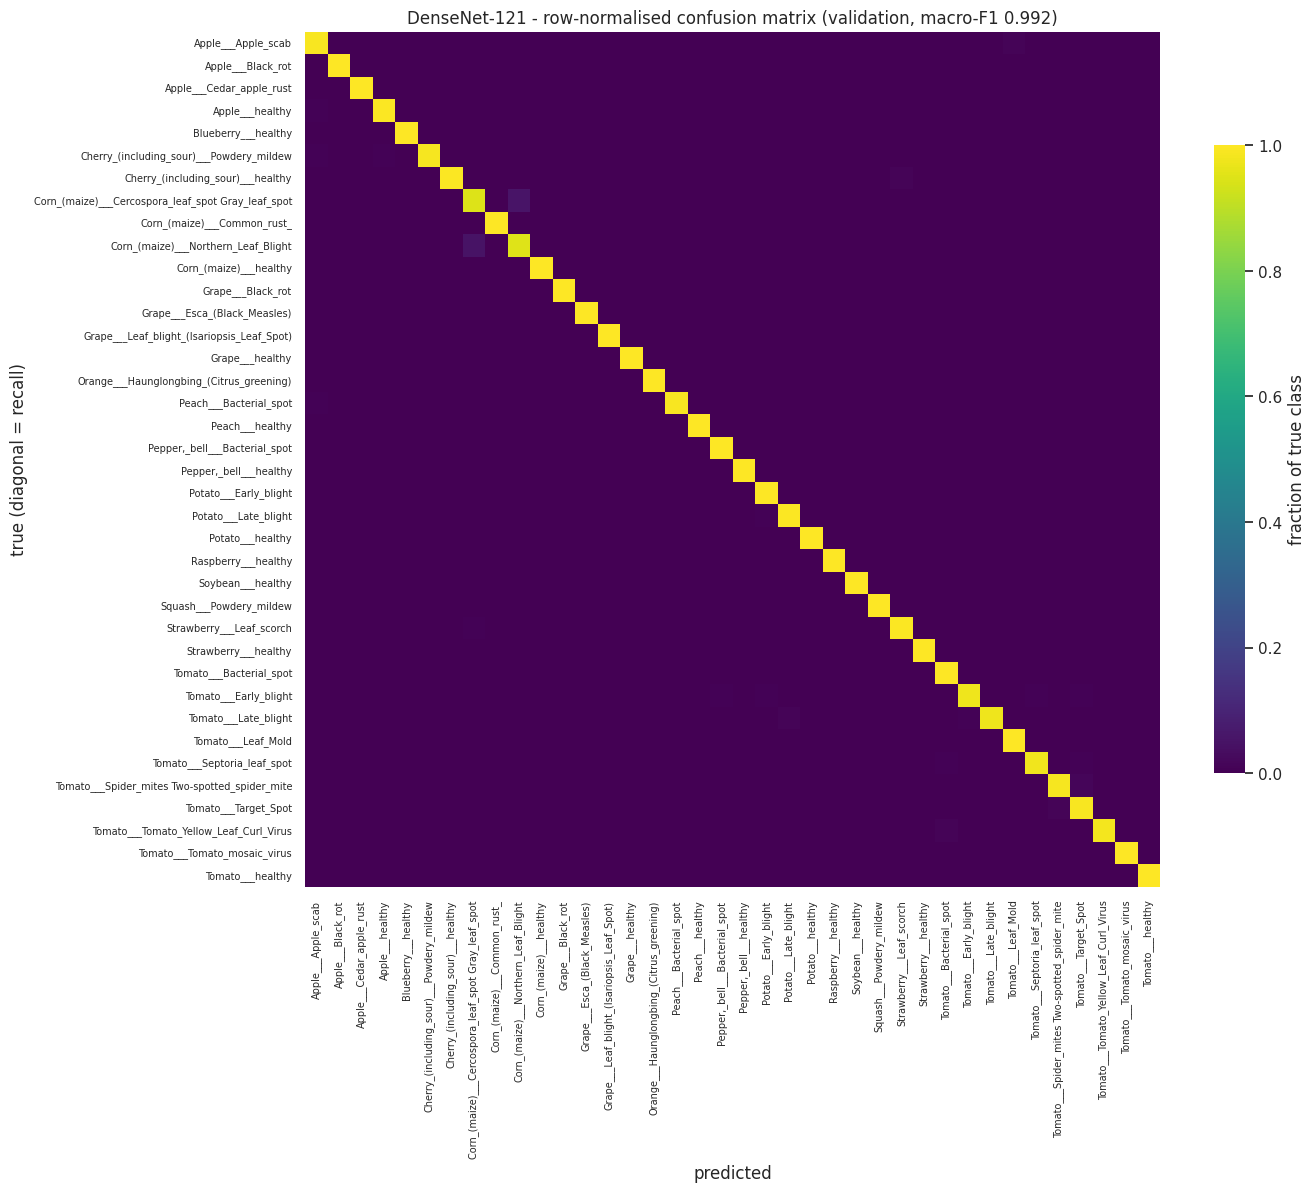

wrote: /content/drive/MyDrive/plant_recognition/deliverable2/04_figures/densenet121_confusion_matrix.png


In [ ]:
# Confusion matrix -> 04_figures/
cm = confusion_matrix(y_true, y_pred, labels=range(n_classes)).astype(float)
cm_norm = np.divide(cm, cm.sum(axis=1, keepdims=True),
                    out=np.zeros_like(cm), where=cm.sum(axis=1, keepdims=True) > 0)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, cmap="viridis", vmin=0, vmax=1, square=True,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={"shrink": 0.7, "label": "fraction of true class"})
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.xlabel("predicted"); plt.ylabel("true (diagonal = recall)")
plt.title(f"DenseNet-121 - row-normalised confusion matrix (validation, macro-F1 {macro_f1:.3f})")
plt.tight_layout()
cm_path = FIGURES / f"{TAG}_confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight"); plt.show()
print("wrote:", cm_path)

pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(RESULTS / f"{TAG}_confusion_matrix.csv")

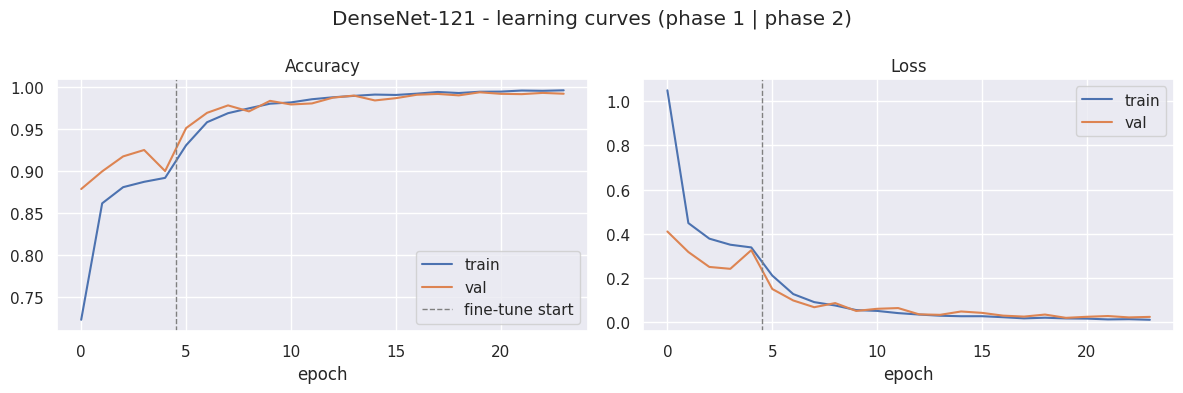

wrote: /content/drive/MyDrive/plant_recognition/deliverable2/04_figures/densenet121_learning_curves.png


In [ ]:
# Learning curves across both phases -> 04_figures/  (only if training ran or a history exists)
if h1 and h2:
    hist = {k: h1[k] + h2[k] for k in h1}
    boundary = len(h1["loss"])
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["accuracy"], label="train"); ax[0].plot(hist["val_accuracy"], label="val")
    ax[0].axvline(boundary - 0.5, ls="--", c="gray", lw=1, label="fine-tune start")
    ax[0].set_title("Accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(hist["loss"], label="train"); ax[1].plot(hist["val_loss"], label="val")
    ax[1].axvline(boundary - 0.5, ls="--", c="gray", lw=1)
    ax[1].set_title("Loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.suptitle("DenseNet-121 - learning curves (phase 1 | phase 2)")
    plt.tight_layout()
    lc_path = FIGURES / f"{TAG}_learning_curves.png"
    plt.savefig(lc_path, dpi=150, bbox_inches="tight"); plt.show()
    print("wrote:", lc_path)
else:
    print("No history in this session (model was loaded from Drive) - learning curves skipped.")

## 11. What this run produced

One place to copy from into Table 1, and the list of files to check before you close the runtime.

In [ ]:
# Run receipt
print("=" * 66)
print("09 - DenseNet-121 transfer learning")
print("=" * 66)
print(f"SPLIT_ID              {SPLIT_ID}   (expected {SPLIT_ID_EXPECTED})")
print(f"val macro-F1          {macro_f1:.4f}")
print(f"val accuracy          {accuracy:.4f}")
print(f"min per-class recall  {per_class['recall'].min():.4f}")
print(f"total parameters      {model.count_params():,}")
if h1 and h2:
    print(f"epochs                {len(h1['loss'])} (phase 1) + {len(h2['loss'])} (phase 2)")
    print(f"training time         {(t_phase1 + t_phase2)/60:.1f} min" if TRAIN_NEEDED else "")
print()
for d in (MODELS_DIR, RESULTS, FIGURES):
    files = sorted(f for f in d.glob(f"*{TAG.split('_smoke')[0]}*") if f.is_file())
    print(f"{d.name}/")
    for f in files:
        print(f"   {f.name}  ({f.stat().st_size/1e6:.2f} MB)")
print()
if SMOKE_TEST:
    print("SMOKE_TEST was True - these numbers are meaningless. Set it to False and Run all.")
else:
    print("Sanity check: expected macro-F1 ~0.993, min per-class recall ~0.946.")
    print("More than ~0.01 off means something changed - check SPLIT_ID first.")

09 - DenseNet-121 transfer learning
SPLIT_ID              9e33ec57c1ec   (expected 9e33ec57c1ec)
val macro-F1          0.9918
val accuracy          0.9931
min per-class recall  0.9481
total parameters      7,076,454
epochs                5 (phase 1) + 19 (phase 2)
training time         72.2 min

02_models/
   densenet121.keras  (85.20 MB)
03_results/
   densenet121_classification_report.txt  (0.00 MB)
   densenet121_confusion_matrix.csv  (0.01 MB)
   densenet121_history.json  (0.00 MB)
   densenet121_per_class_recall.csv  (0.00 MB)
   densenet121_results.csv  (0.00 MB)
04_figures/
   densenet121_confusion_matrix.png  (0.32 MB)
   densenet121_learning_curves.png  (0.09 MB)

Sanity check: expected macro-F1 ~0.993, min per-class recall ~0.946.
More than ~0.01 off means something changed - check SPLIT_ID first.
